# Laboratory Activity 2 – Binary Classification Using Logistic Regression
## Students' Employability Dataset – Philippines

This notebook is a complete worked example for the Logistic Regression laboratory activity using the dataset requested by the instructor.

### Dataset Source
**Kaggle:** Students' Employability Dataset – Philippines  
https://www.kaggle.com/datasets/anashamoutni/students-employability-dataset

### Classification Task
Predict whether a student is classified as:

- **Employable**
- **LessEmployable**

based on mock job-interview ratings.

### Important Modeling Note
The column **`Name of Student`** is an identifier rather than a meaningful predictive characteristic. It will therefore be excluded from the Logistic Regression model instead of being encoded.


# 1. Import Libraries and Load the Dataset

In [2]:
# Core libraries
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Statistical diagnostics
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


In [2]:
# Load the Excel file supplied with this sample.
# Change the path if your file is stored elsewhere.

data_file = Path("/mnt/data/Student-Employability-Datasets.xlsx")

if not data_file.exists():
    raise FileNotFoundError(
        "Student-Employability-Datasets.xlsx was not found. "
        "Place the file in /mnt/data or update data_file."
    )

df = pd.read_excel(data_file, sheet_name="Data")

print("Dataset loaded successfully.")
df.head()


Dataset loaded successfully.


,Name of Student,GENERAL APPEARANCE,MANNER OF SPEAKING,PHYSICAL CONDITION,MENTAL ALERTNESS,SELF-CONFIDENCE,ABILITY TO PRESENT IDEAS,COMMUNICATION SKILLS,Student Performance Rating,CLASS
0,Student 1,4,5,4,5,5,5,5,5,Employable
1,Student 2,4,4,4,4,4,4,3,5,Employable
2,Student 3,4,3,3,3,3,3,2,5,LessEmployable
3,Student 4,3,3,3,2,3,3,3,5,LessEmployable
4,Student 5,4,4,3,3,4,4,3,5,Employable


# 2. Dataset Context and Description

The dataset contains results from **mock job interviews of 2,982 students** in the Philippines. Each student is rated on eight interview-related characteristics. The final `CLASS` variable indicates whether the student was classified as **Employable** or **LessEmployable**.

The eight predictive ratings are:

1. `GENERAL APPEARANCE`
2. `MANNER OF SPEAKING`
3. `PHYSICAL CONDITION`
4. `MENTAL ALERTNESS`
5. `SELF-CONFIDENCE`
6. `ABILITY TO PRESENT IDEAS`
7. `COMMUNICATION SKILLS`
8. `Student Performance Rating`

Most ratings use values from **2 to 5**, while Student Performance Rating uses values from **3 to 5** in this dataset.

## Target Variable

`CLASS`

- `Employable`
- `LessEmployable`

## Identifier

`Name of Student`

This variable identifies individual records but does not represent an employability skill. It is excluded from the predictive model.


# 3. Problem Statement and Objectives

## Problem Statement

Can a student's mock job-interview ratings be used to predict whether the student is classified as Employable or LessEmployable?

## General Objective

To develop and evaluate a Logistic Regression model that predicts student employability classification using mock job-interview performance ratings.

## Specific Objectives

1. Describe and inspect the Students' Employability dataset.
2. Identify the dependent variable, independent variables, and identifier column.
3. Check data quality through missing-value, duplicate, range, and class-distribution analysis.
4. Perform exploratory data analysis on the interview-rating variables.
5. Examine correlations and possible multicollinearity among predictors.
6. Evaluate important Logistic Regression assumptions and conditions.
7. Properly preprocess the numerical predictors and non-numerical target.
8. Split the dataset into 80% training and 20% testing data.
9. Train a Logistic Regression classification model.
10. Evaluate the model using a confusion matrix, accuracy, precision, recall, F1-score, and classification report.
11. Interpret the model results and formulate a conclusion.


# 4. Initial Data Inspection

In [3]:
print(f"Number of observations: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")

print("\nColumn names:")
for column in df.columns:
    print("-", column)


Number of observations: 2,982
Number of columns: 10

Column names:
- Name of Student
- GENERAL APPEARANCE
- MANNER OF SPEAKING
- PHYSICAL CONDITION
- MENTAL ALERTNESS
- SELF-CONFIDENCE
- ABILITY TO PRESENT IDEAS
- COMMUNICATION SKILLS
- Student Performance Rating
- CLASS


In [4]:
# View data types and non-null counts.
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2982 entries, 0 to 2981
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Name of Student             2982 non-null   object
 1   GENERAL APPEARANCE          2982 non-null   int64 
 2   MANNER OF SPEAKING          2982 non-null   int64 
 3   PHYSICAL CONDITION          2982 non-null   int64 
 4   MENTAL ALERTNESS            2982 non-null   int64 
 5   SELF-CONFIDENCE             2982 non-null   int64 
 6   ABILITY TO PRESENT IDEAS    2982 non-null   int64 
 7   COMMUNICATION SKILLS        2982 non-null   int64 
 8   Student Performance Rating  2982 non-null   int64 
 9   CLASS                       2982 non-null   object
dtypes: int64(8), object(2)
memory usage: 233.1+ KB


In [5]:
# Summary statistics for numerical columns.
df.describe().T


,count,mean,std,min,25%,50%,75%,max
GENERAL APPEARANCE,"2,982.000",4.247,0.679,2.000,4.000,4.000,5.000,5.000
MANNER OF SPEAKING,"2,982.000",3.885,0.757,2.000,3.000,4.000,4.000,5.000
PHYSICAL CONDITION,"2,982.000",3.972,0.744,2.000,3.000,4.000,5.000,5.000
MENTAL ALERTNESS,"2,982.000",3.963,0.782,2.000,3.000,4.000,5.000,5.000
SELF-CONFIDENCE,"2,982.000",3.911,0.808,2.000,3.000,4.000,5.000,5.000
ABILITY TO PRESENT IDEAS,"2,982.000",3.814,0.739,2.000,3.000,4.000,4.000,5.000
COMMUNICATION SKILLS,"2,982.000",3.525,0.744,2.000,3.000,3.000,4.000,5.000
Student Performance Rating,"2,982.000",4.611,0.693,3.000,4.000,5.000,5.000,5.000


In [6]:
# Missing-value count and percentage.
missing_summary = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percent": (df.isna().mean() * 100).round(2)
}).sort_values("Missing_Count", ascending=False)

missing_summary


,Missing_Count,Missing_Percent
Name of Student,0,0.000
GENERAL APPEARANCE,0,0.000
MANNER OF SPEAKING,0,0.000
PHYSICAL CONDITION,0,0.000
MENTAL ALERTNESS,0,0.000
SELF-CONFIDENCE,0,0.000
ABILITY TO PRESENT IDEAS,0,0.000
COMMUNICATION SKILLS,0,0.000
Student Performance Rating,0,0.000
CLASS,0,0.000


In [7]:
# Check duplicate records.
print("Exact duplicate rows:", df.duplicated().sum())

# Check whether student names are unique.
print(
    "Unique student names:",
    df["Name of Student"].nunique()
)
print(
    "Total records:",
    len(df)
)


Exact duplicate rows: 0
Unique student names: 2982
Total records: 2982


### Initial Inspection Interpretation

- The dataset contains **2,982 student records** and **10 columns**.
- There are eight interview-rating predictors, one identifier, and one target variable.
- The dataset contains no conventional missing values.
- Exact duplicate rows are checked before any modeling decisions are made.
- `Name of Student` should not be converted to numeric codes or one-hot encoded because a student's name is an identifier rather than a meaningful employability predictor.


# 5. Data Dictionary and Variable Roles

In [8]:
data_dictionary = pd.DataFrame({
    "Variable": [
        "Name of Student",
        "GENERAL APPEARANCE",
        "MANNER OF SPEAKING",
        "PHYSICAL CONDITION",
        "MENTAL ALERTNESS",
        "SELF-CONFIDENCE",
        "ABILITY TO PRESENT IDEAS",
        "COMMUNICATION SKILLS",
        "Student Performance Rating",
        "CLASS"
    ],
    "Data Type / Measurement": [
        "Text / Identifier",
        "Ordinal numeric rating",
        "Ordinal numeric rating",
        "Ordinal numeric rating",
        "Ordinal numeric rating",
        "Ordinal numeric rating",
        "Ordinal numeric rating",
        "Ordinal numeric rating",
        "Ordinal numeric rating",
        "Categorical / Binary"
    ],
    "Role": [
        "Excluded identifier",
        "Predictor",
        "Predictor",
        "Predictor",
        "Predictor",
        "Predictor",
        "Predictor",
        "Predictor",
        "Predictor",
        "Target"
    ]
})

data_dictionary


,Variable,Data Type / Measurement,Role
0,Name of Student,Text / Identifier,Excluded identifier
1,GENERAL APPEARANCE,Ordinal numeric rating,Predictor
2,MANNER OF SPEAKING,Ordinal numeric rating,Predictor
3,PHYSICAL CONDITION,Ordinal numeric rating,Predictor
4,MENTAL ALERTNESS,Ordinal numeric rating,Predictor
5,SELF-CONFIDENCE,Ordinal numeric rating,Predictor
6,ABILITY TO PRESENT IDEAS,Ordinal numeric rating,Predictor
7,COMMUNICATION SKILLS,Ordinal numeric rating,Predictor
8,Student Performance Rating,Ordinal numeric rating,Predictor
9,CLASS,Categorical / Binary,Target


# 6. Proper Data Preprocessing

This dataset requires a slightly different preprocessing strategy from datasets that contain nominal categorical predictors.

## Numerical / Ordinal Predictors

The eight interview ratings are already stored as numbers. They will be:

- checked for valid ranges;
- kept as predictors; and
- standardized using `StandardScaler` **after the train-test split**.

Standardization is not strictly required for Logistic Regression, but it places all coefficients on a more comparable scale and is a good preprocessing practice.

## Non-Numerical Variables

### `Name of Student`
This is an identifier. It is **dropped**, not encoded.

### `CLASS`
This is the binary target and must be encoded as:

- `Employable = 1`
- `LessEmployable = 0`

## Why is One-Hot Encoding Not Used?

After removing the student-name identifier, this dataset has **no nominal categorical input predictor**. Therefore, applying one-hot encoding to the predictors would be unnecessary.

The rating predictors are ordinal and already represented numerically.


In [9]:
predictor_columns = [
    "GENERAL APPEARANCE",
    "MANNER OF SPEAKING",
    "PHYSICAL CONDITION",
    "MENTAL ALERTNESS",
    "SELF-CONFIDENCE",
    "ABILITY TO PRESENT IDEAS",
    "COMMUNICATION SKILLS",
    "Student Performance Rating",
]

target_column = "CLASS"

X = df[predictor_columns].copy()

y = df[target_column].map({
    "LessEmployable": 0,
    "Employable": 1
})

print("Predictor shape:", X.shape)
print("Target unique values:", sorted(y.unique()))

X.head()


Predictor shape: (2982, 8)
Target unique values: [np.int64(0), np.int64(1)]


,GENERAL APPEARANCE,MANNER OF SPEAKING,PHYSICAL CONDITION,MENTAL ALERTNESS,SELF-CONFIDENCE,ABILITY TO PRESENT IDEAS,COMMUNICATION SKILLS,Student Performance Rating
0,4,5,4,5,5,5,5,5
1,4,4,4,4,4,4,3,5
2,4,3,3,3,3,3,2,5
3,3,3,3,2,3,3,3,5
4,4,4,3,3,4,4,3,5


# 7. Data Quality and Valid-Range Checking

The feature values are mock-interview ratings. Before modeling, their actual observed ranges should be checked for impossible or unexpected values.


In [10]:
range_table = pd.DataFrame({
    "Minimum": X.min(),
    "Maximum": X.max(),
    "Unique_Values": [
        sorted(X[column].unique().tolist())
        for column in X.columns
    ]
})

range_table


,Minimum,Maximum,Unique_Values
GENERAL APPEARANCE,2,5,"[2, 3, 4, 5]"
MANNER OF SPEAKING,2,5,"[2, 3, 4, 5]"
PHYSICAL CONDITION,2,5,"[2, 3, 4, 5]"
MENTAL ALERTNESS,2,5,"[2, 3, 4, 5]"
SELF-CONFIDENCE,2,5,"[2, 3, 4, 5]"
ABILITY TO PRESENT IDEAS,2,5,"[2, 3, 4, 5]"
COMMUNICATION SKILLS,2,5,"[2, 3, 4, 5]"
Student Performance Rating,3,5,"[3, 4, 5]"


### Range Interpretation

The observed scores fall within narrow rating scales:

- Most predictor variables contain scores from **2 to 5**.
- `Student Performance Rating` contains scores from **3 to 5**.

There are no values outside these observed rating scales. No records are removed on the basis of invalid scores.


# 8. Exploratory Data Analysis (EDA)

## 8.1 Dataset Shape

In [11]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Model predictors:", X.shape[1])


Rows: 2982
Columns: 10
Model predictors: 8


## 8.2 Missing Values

In [12]:
X.isna().sum().to_frame("Missing_Count")


,Missing_Count
GENERAL APPEARANCE,0
MANNER OF SPEAKING,0
PHYSICAL CONDITION,0
MENTAL ALERTNESS,0
SELF-CONFIDENCE,0
ABILITY TO PRESENT IDEAS,0
COMMUNICATION SKILLS,0
Student Performance Rating,0


### Missing-Value Interpretation

There are no missing values among the model predictors. No imputation is required for this dataset.


## 8.3 Target Value Counts and Class Distribution

In [13]:
class_counts = df["CLASS"].value_counts()
class_percent = (
    df["CLASS"].value_counts(normalize=True) * 100
).round(2)

class_distribution = pd.DataFrame({
    "Count": class_counts,
    "Percent": class_percent
})

class_distribution


,Count,Percent
CLASS,,
Employable,1729,57.980
LessEmployable,1253,42.020


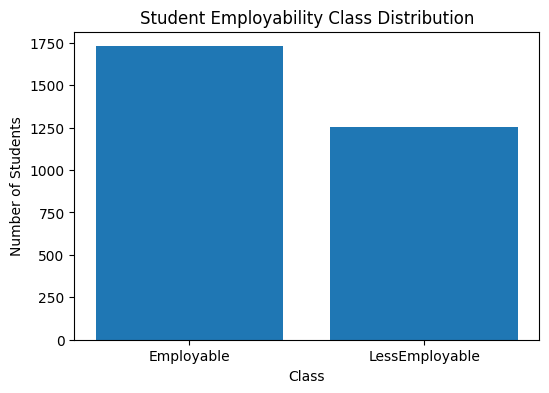

In [14]:
plt.figure(figsize=(6, 4))
plt.bar(
    class_counts.index,
    class_counts.values
)
plt.title("Student Employability Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Students")
plt.show()


### Class-Distribution Interpretation

The dataset contains more **Employable** students than **LessEmployable** students. The imbalance is noticeable but not extreme, because both classes still contain more than one thousand observations.

Accuracy should still be interpreted together with precision, recall, F1-score, and the confusion matrix.


## 8.4 Value Counts for Each Interview Rating

In [15]:
for column in predictor_columns:
    print(f"\n--- {column} ---")
    print(
        df[column]
        .value_counts()
        .sort_index()
    )



--- GENERAL APPEARANCE ---
GENERAL APPEARANCE
2      16
3     361
4    1476
5    1129
Name: count, dtype: int64

--- MANNER OF SPEAKING ---
MANNER OF SPEAKING
2      48
3     902
4    1378
5     654
Name: count, dtype: int64

--- PHYSICAL CONDITION ---
PHYSICAL CONDITION
2      32
3     772
4    1425
5     753
Name: count, dtype: int64

--- MENTAL ALERTNESS ---
MENTAL ALERTNESS
2      66
3     771
4    1353
5     792
Name: count, dtype: int64

--- SELF-CONFIDENCE ---
SELF-CONFIDENCE
2      33
3    1018
4    1113
5     818
Name: count, dtype: int64

--- ABILITY TO PRESENT IDEAS ---
ABILITY TO PRESENT IDEAS
2      82
3     898
4    1495
5     507
Name: count, dtype: int64

--- COMMUNICATION SKILLS ---
COMMUNICATION SKILLS
2     164
3    1376
4    1153
5     289
Name: count, dtype: int64

--- Student Performance Rating ---
Student Performance Rating
3     361
4     439
5    2182
Name: count, dtype: int64


## 8.5 Distribution of Predictor Ratings

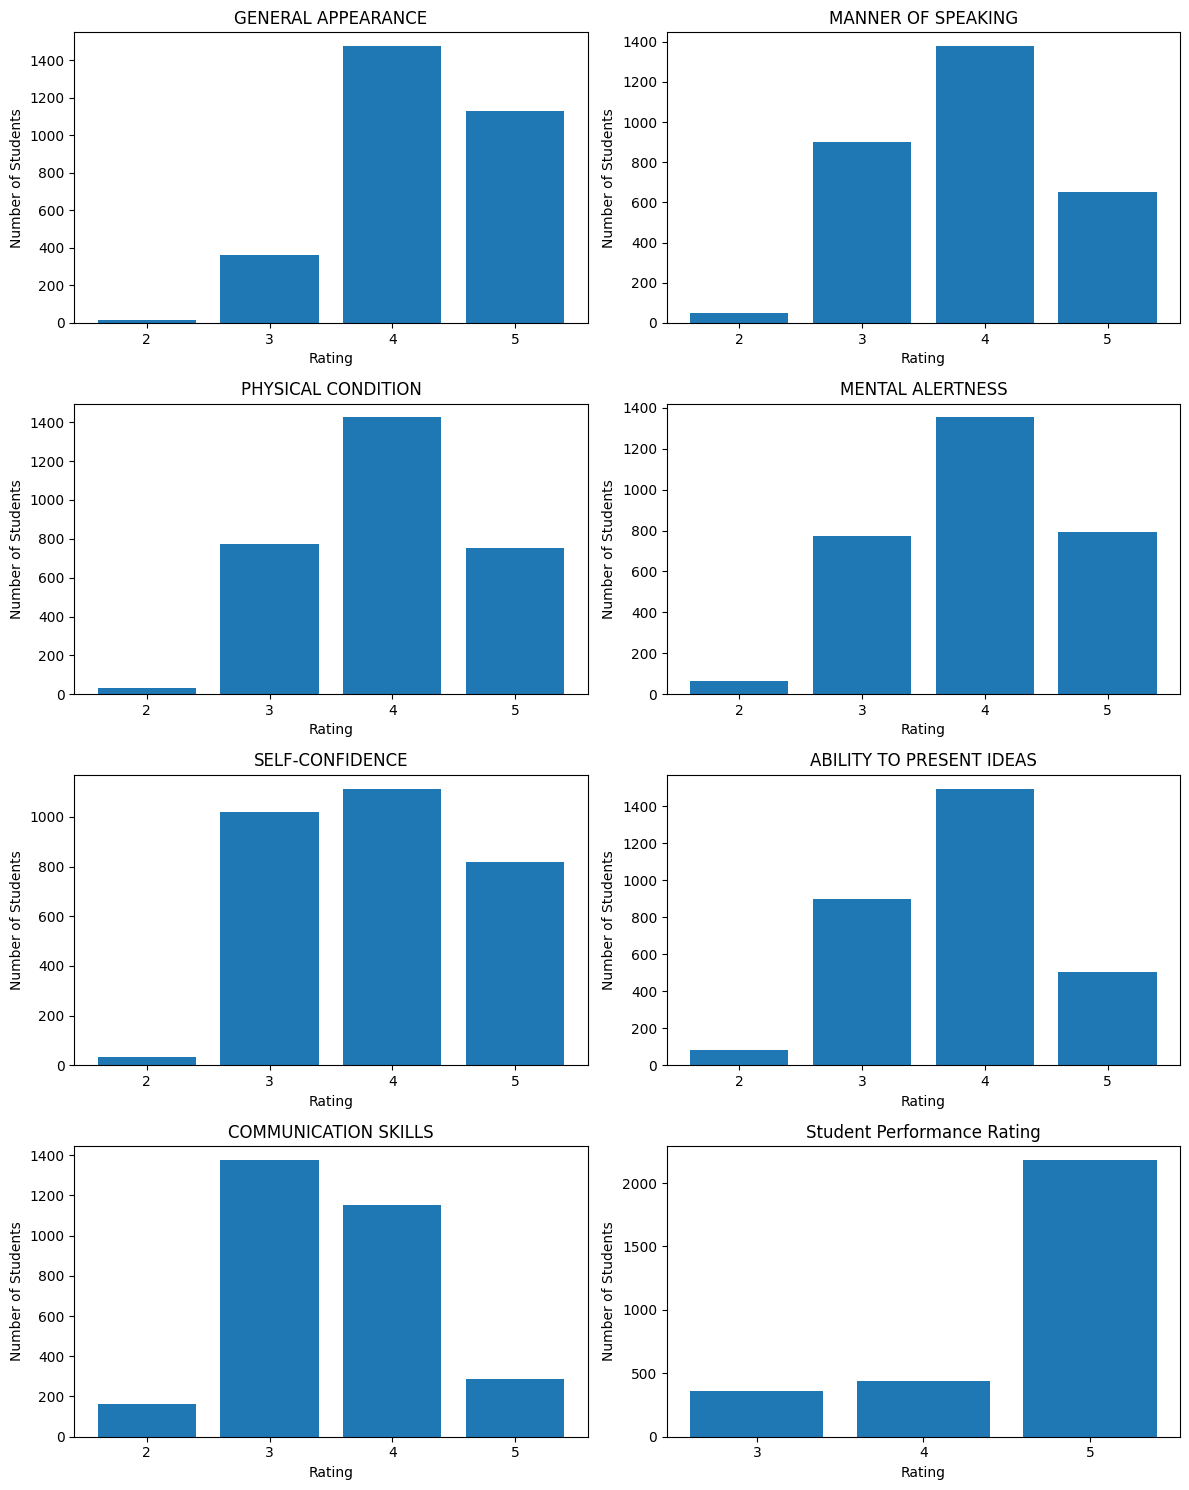

In [16]:
fig, axes = plt.subplots(4, 2, figsize=(12, 15))

for ax, column in zip(
    axes.ravel(),
    predictor_columns
):
    counts = (
        df[column]
        .value_counts()
        .sort_index()
    )

    ax.bar(
        counts.index.astype(str),
        counts.values
    )
    ax.set_title(column)
    ax.set_xlabel("Rating")
    ax.set_ylabel("Number of Students")

plt.tight_layout()
plt.show()


### Distribution Interpretation

Because the predictors are discrete ordinal ratings rather than continuous measurements, bar charts are more informative than smooth density plots.

The charts show how frequently students received each rating. They also make it possible to identify whether a variable is concentrated around particular rating levels.


## 8.6 Descriptive Statistics

In [17]:
X.describe().T


,count,mean,std,min,25%,50%,75%,max
GENERAL APPEARANCE,"2,982.000",4.247,0.679,2.000,4.000,4.000,5.000,5.000
MANNER OF SPEAKING,"2,982.000",3.885,0.757,2.000,3.000,4.000,4.000,5.000
PHYSICAL CONDITION,"2,982.000",3.972,0.744,2.000,3.000,4.000,5.000,5.000
MENTAL ALERTNESS,"2,982.000",3.963,0.782,2.000,3.000,4.000,5.000,5.000
SELF-CONFIDENCE,"2,982.000",3.911,0.808,2.000,3.000,4.000,5.000,5.000
ABILITY TO PRESENT IDEAS,"2,982.000",3.814,0.739,2.000,3.000,4.000,4.000,5.000
COMMUNICATION SKILLS,"2,982.000",3.525,0.744,2.000,3.000,3.000,4.000,5.000
Student Performance Rating,"2,982.000",4.611,0.693,3.000,4.000,5.000,5.000,5.000


### Descriptive-Statistics Interpretation

The mean and standard deviation summarize the central tendency and spread of each interview rating. Because the variables use short ordinal scales, these statistics should be interpreted together with the frequency distributions rather than treated as precise continuous measurements.


## 8.7 Ratings Compared with Employability Class

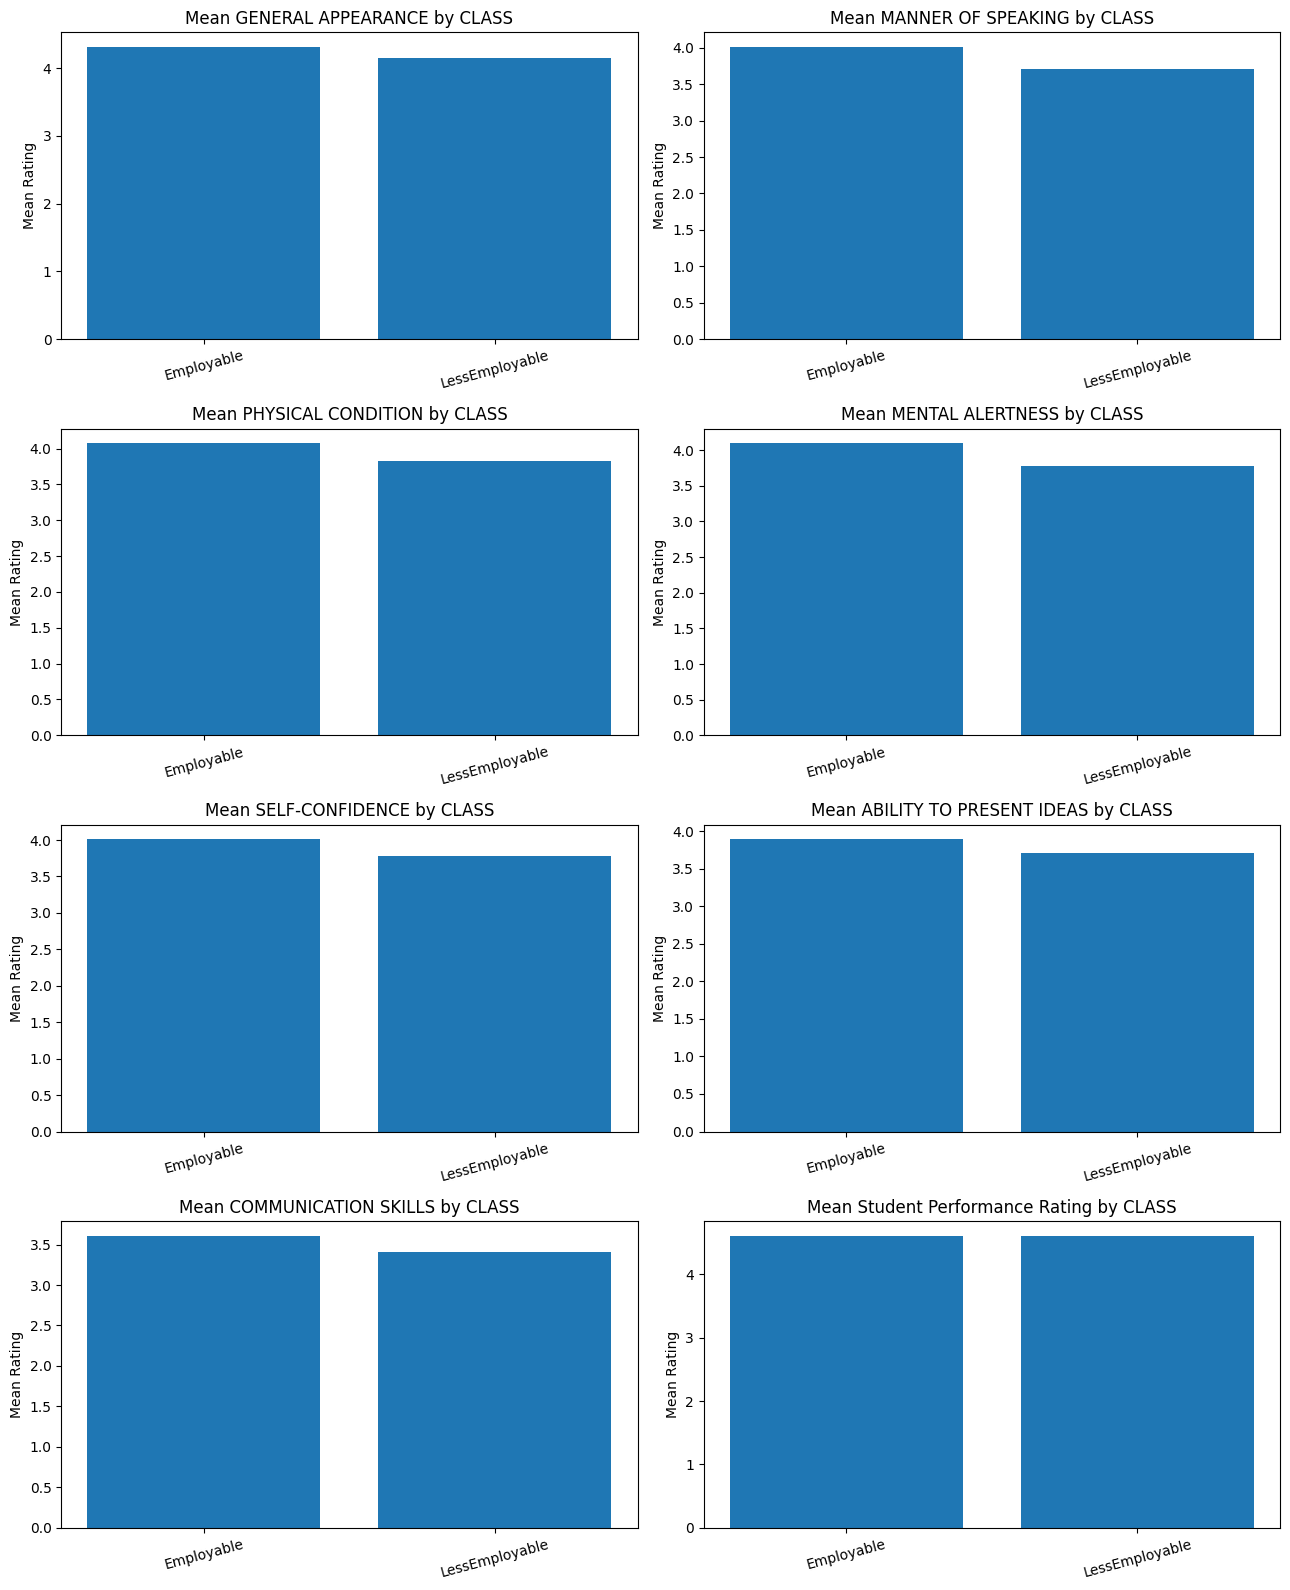

In [18]:
fig, axes = plt.subplots(4, 2, figsize=(13, 16))

for ax, column in zip(
    axes.ravel(),
    predictor_columns
):
    group_means = (
        df.groupby("CLASS")[column]
        .mean()
    )

    ax.bar(
        group_means.index,
        group_means.values
    )
    ax.set_title(f"Mean {column} by CLASS")
    ax.set_ylabel("Mean Rating")
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()


### Group-Comparison Interpretation

The group means provide an initial descriptive comparison between Employable and LessEmployable students.

Variables such as **Mental Alertness** and **Manner of Speaking** tend to show noticeable differences between the two classes. `Student Performance Rating` shows little difference in its simple association with the class in this dataset.

These are descriptive relationships and should not automatically be interpreted as causal effects.


## 8.8 Correlation Matrix Among Predictors

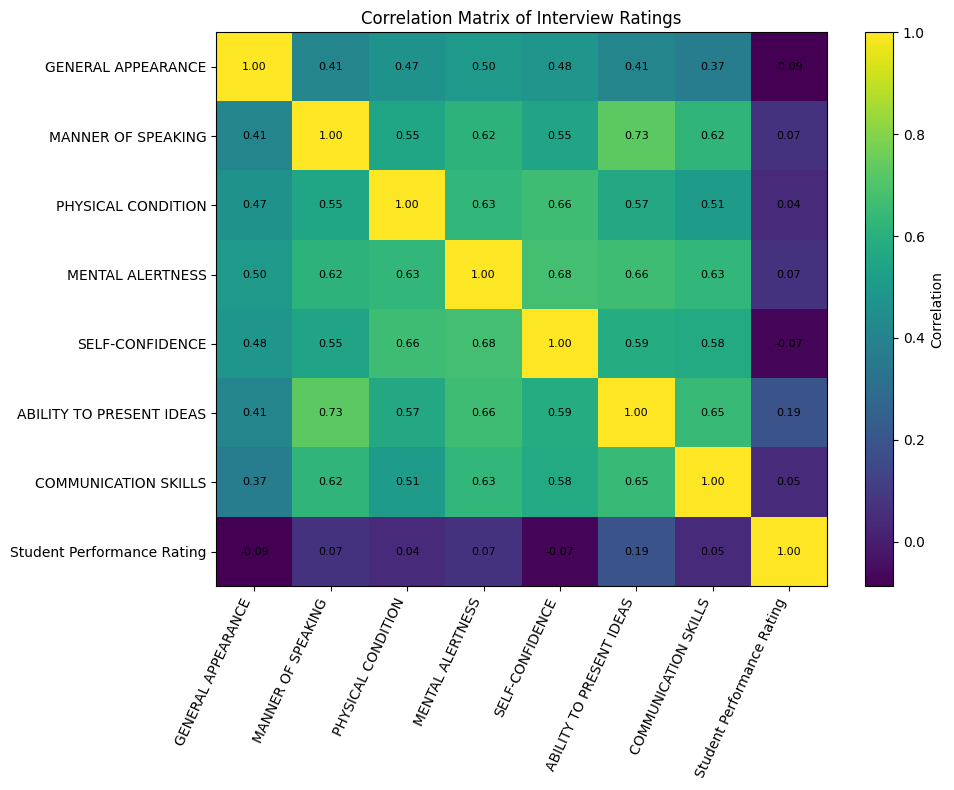

,GENERAL APPEARANCE,MANNER OF SPEAKING,PHYSICAL CONDITION,MENTAL ALERTNESS,SELF-CONFIDENCE,ABILITY TO PRESENT IDEAS,COMMUNICATION SKILLS,Student Performance Rating
GENERAL APPEARANCE,1.000,0.407,0.469,0.496,0.480,0.407,0.371,-0.087
MANNER OF SPEAKING,0.407,1.000,0.551,0.617,0.549,0.726,0.623,0.072
PHYSICAL CONDITION,0.469,0.551,1.000,0.635,0.663,0.570,0.514,0.041
MENTAL ALERTNESS,0.496,0.617,0.635,1.000,0.675,0.662,0.631,0.074
SELF-CONFIDENCE,0.480,0.549,0.663,0.675,1.000,0.588,0.577,-0.069
ABILITY TO PRESENT IDEAS,0.407,0.726,0.570,0.662,0.588,1.000,0.648,0.192
COMMUNICATION SKILLS,0.371,0.623,0.514,0.631,0.577,0.648,1.000,0.048
Student Performance Rating,-0.087,0.072,0.041,0.074,-0.069,0.192,0.048,1.000


In [19]:
corr_matrix = X.corr()

plt.figure(figsize=(10, 8))
plt.imshow(
    corr_matrix,
    aspect="auto"
)
plt.colorbar(label="Correlation")

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=65,
    ha="right"
)
plt.yticks(
    range(len(corr_matrix.index)),
    corr_matrix.index
)

for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        plt.text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.title("Correlation Matrix of Interview Ratings")
plt.tight_layout()
plt.show()

corr_matrix


### Correlation Interpretation

Several interview skills are moderately positively correlated. This is reasonable because related traits such as communication, confidence, mental alertness, and idea presentation may occur together.

No pair of predictors shows an extremely high correlation in the simple correlation matrix, but VIF will be used later as an additional multicollinearity diagnostic.


## 8.9 Predictor Correlation with Encoded Employability

In [20]:
eda_with_target = X.copy()
eda_with_target["Employable_Encoded"] = y

target_correlations = (
    eda_with_target
    .corr()["Employable_Encoded"]
    .drop("Employable_Encoded")
    .sort_values(ascending=False)
)

target_correlations.to_frame(
    "Correlation_with_Employability"
)


,Correlation_with_Employability
MENTAL ALERTNESS,0.203
MANNER OF SPEAKING,0.198
PHYSICAL CONDITION,0.164
SELF-CONFIDENCE,0.142
COMMUNICATION SKILLS,0.133
ABILITY TO PRESENT IDEAS,0.117
GENERAL APPEARANCE,0.116
Student Performance Rating,-0.001


### Target-Correlation Interpretation

The simple correlations show that **Mental Alertness** and **Manner of Speaking** have the strongest positive associations with the encoded employability class among the available predictors.

`Student Performance Rating` has almost no simple linear correlation with the target in this dataset.

Correlation is useful for exploration, but Logistic Regression evaluates the predictors together rather than one at a time.


# 9. Split the Data into Training and Testing Sets

The dataset will be divided into:

- **80% training data**
- **20% testing data**

Stratification is used so that both subsets retain similar proportions of Employable and LessEmployable students.


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

print("\nTraining class proportions:")
print(
    y_train
    .value_counts(normalize=True)
    .sort_index()
    .round(3)
)

print("\nTesting class proportions:")
print(
    y_test
    .value_counts(normalize=True)
    .sort_index()
    .round(3)
)


X_train shape: (2385, 8)
X_test shape : (597, 8)
y_train shape: (2385,)
y_test shape : (597,)

Training class proportions:
CLASS
0   0.420
1   0.580
Name: proportion, dtype: float64

Testing class proportions:
CLASS
0   0.420
1   0.580
Name: proportion, dtype: float64


### Train-Test Split Interpretation

The training set is used to estimate the Logistic Regression model. The testing set is kept unseen during model training so it can provide a more realistic evaluation of performance on new observations.

The use of `stratify=y` keeps the employability-class proportions similar in both subsets.


# 10. Logistic Regression Assumption / Condition Checking

## 10.1 Binary Dependent Variable

In [22]:
print(
    "Original target values:",
    df["CLASS"].unique()
)
print(
    "Encoded target values:",
    sorted(y.unique())
)
print(
    "Number of target classes:",
    y.nunique()
)


Original target values: ['Employable' 'LessEmployable']
Encoded target values: [np.int64(0), np.int64(1)]
Number of target classes: 2


**Interpretation:** The target contains exactly two categories and is correctly encoded as 0 and 1. The binary-outcome requirement is satisfied.


## 10.2 Independence of Observations

Each row represents a named student record. The student-name column can be used to check whether every observation corresponds to a unique student identifier.


In [23]:
print(
    "Total rows:",
    len(df)
)
print(
    "Unique student names:",
    df["Name of Student"].nunique()
)
print(
    "Duplicated student names:",
    df["Name of Student"].duplicated().sum()
)


Total rows: 2982
Unique student names: 2982
Duplicated student names: 0


### Independence Interpretation

The student identifiers are unique in the provided dataset, so there are no obvious repeated student records based on the name field.

This supports the assumption that the observations represent different students. However, statistical independence ultimately also depends on how the data were collected, so the dataset documentation should be considered when making a stronger claim.


## 10.3 Appropriate Sample Size and Class Counts

In [24]:
sample_size_table = pd.DataFrame({
    "Training": y_train.value_counts().sort_index(),
    "Testing": y_test.value_counts().sort_index()
})

sample_size_table.index = [
    "LessEmployable (0)",
    "Employable (1)"
]

sample_size_table


,Training,Testing
LessEmployable (0),1002,251
Employable (1),1383,346


### Sample-Size Interpretation

Both classes have hundreds of observations in the test set and more than one thousand total observations in the full dataset. The sample is adequate for fitting a basic Logistic Regression model with eight predictors.

The classes are moderately imbalanced but neither class is extremely rare.


## 10.4 Multicollinearity Using Variance Inflation Factor (VIF)

VIF is calculated using **training predictors only**.

As a classroom guideline:

- values near 1 indicate little redundancy;
- moderately larger values indicate some shared information;
- very large values may indicate problematic multicollinearity.

Thresholds should not be treated as absolute rules.


In [25]:
# Standardize the training predictors for numerical stability.
vif_scaler = StandardScaler()
X_train_vif_scaled = vif_scaler.fit_transform(
    X_train
)

vif_table = pd.DataFrame({
    "Feature": predictor_columns,
    "VIF": [
        variance_inflation_factor(
            X_train_vif_scaled,
            i
        )
        for i in range(
            X_train_vif_scaled.shape[1]
        )
    ]
}).sort_values(
    "VIF",
    ascending=False
)

vif_table


,Feature,VIF
5,ABILITY TO PRESENT IDEAS,2.987
3,MENTAL ALERTNESS,2.694
4,SELF-CONFIDENCE,2.495
1,MANNER OF SPEAKING,2.446
2,PHYSICAL CONDITION,2.173
6,COMMUNICATION SKILLS,2.094
0,GENERAL APPEARANCE,1.476
7,Student Performance Rating,1.129


### VIF Interpretation

The VIF values are generally below levels that would normally indicate severe multicollinearity. `Ability to Present Ideas`, `Mental Alertness`, `Self-Confidence`, and `Manner of Speaking` share some information, but there is no clear reason to remove predictors solely because of VIF.

The predictors can be retained for the baseline Logistic Regression model.


## 10.5 Linearity of Predictors with the Log-Odds

Logistic Regression assumes a linear relationship between a numerical predictor and the **log-odds** of the outcome.

These predictors are ordinal scores with only a few possible levels. Instead of assuming linearity automatically, we can calculate an **empirical log-odds** value for each observed rating.

An approximately straight trend supports treating the rating as a single numeric predictor. Strongly irregular patterns suggest that one-hot encoding or another nonlinear representation could be considered.


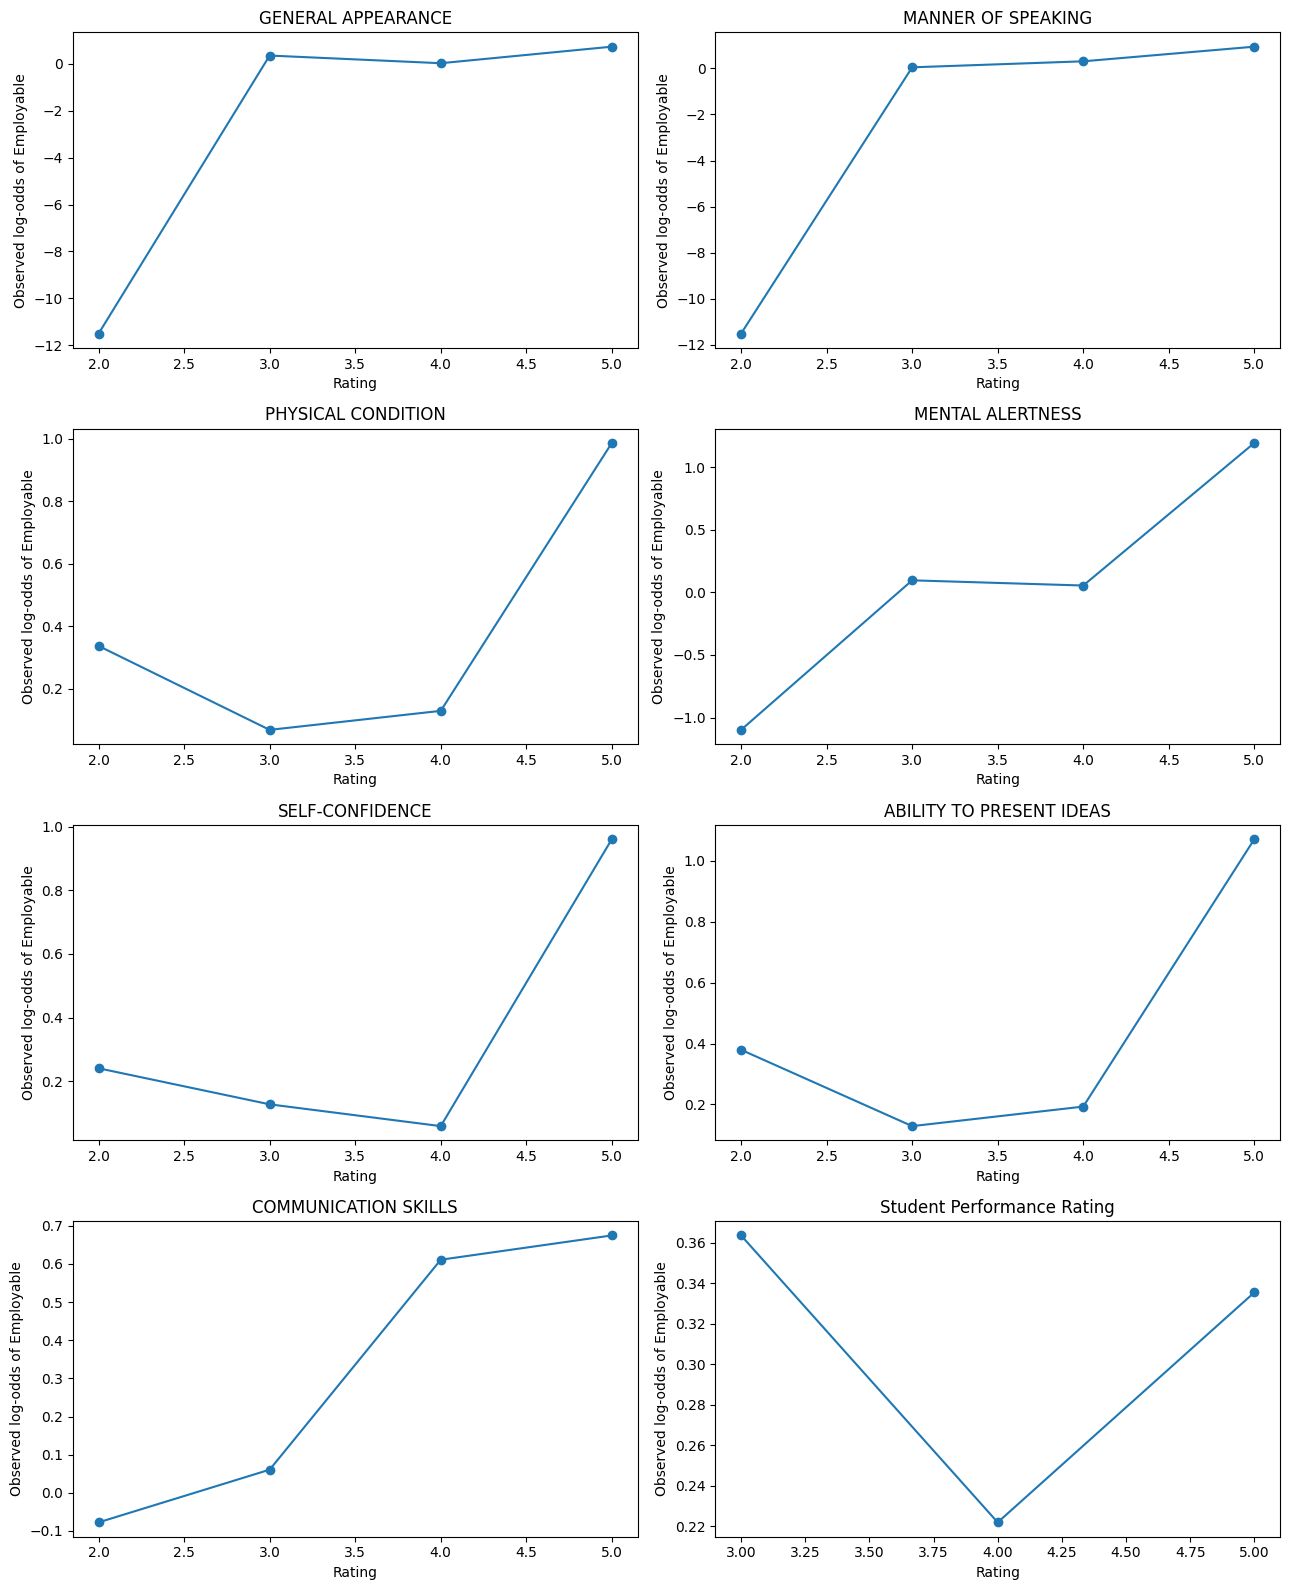

In [26]:
def empirical_logit_by_score(
    X_data,
    y_data,
    feature
):
    temp = pd.DataFrame({
        "score": X_data[feature],
        "target": y_data
    }).dropna()

    summary = (
        temp
        .groupby("score")
        .agg(
            positive_rate=("target", "mean"),
            n=("target", "size")
        )
        .reset_index()
    )

    # Small clipping avoids log(0).
    eps = 1e-5
    p = summary["positive_rate"].clip(
        eps,
        1 - eps
    )

    summary["empirical_log_odds"] = np.log(
        p / (1 - p)
    )

    return summary


fig, axes = plt.subplots(
    4,
    2,
    figsize=(13, 16)
)

for ax, feature in zip(
    axes.ravel(),
    predictor_columns
):
    summary = empirical_logit_by_score(
        X_train,
        y_train,
        feature
    )

    ax.plot(
        summary["score"],
        summary["empirical_log_odds"],
        marker="o"
    )

    ax.set_title(feature)
    ax.set_xlabel("Rating")
    ax.set_ylabel(
        "Observed log-odds of Employable"
    )

plt.tight_layout()
plt.show()


### Log-Odds Linearity Interpretation

Because the predictors contain only three or four score levels, the plots contain only a few points. The linearity condition therefore cannot be evaluated as precisely as it could for truly continuous predictors.

Some variables show reasonably ordered trends, while others may show curvature or inconsistent steps. For the laboratory, the ratings are retained as numeric predictors to build an interpretable baseline model.

A more flexible follow-up model could treat these ratings as categorical levels using one-hot encoding if the empirical log-odds patterns are clearly nonlinear.


## 10.6 Extreme and Invalid Observations

The rating scales are bounded, so checking the actual minimum and maximum values is more meaningful than automatically removing statistical outliers.


In [27]:
validity_check = pd.DataFrame({
    "Minimum": X_train.min(),
    "Maximum": X_train.max(),
    "Unique_Count": X_train.nunique()
})

validity_check


,Minimum,Maximum,Unique_Count
GENERAL APPEARANCE,2,5,4
MANNER OF SPEAKING,2,5,4
PHYSICAL CONDITION,2,5,4
MENTAL ALERTNESS,2,5,4
SELF-CONFIDENCE,2,5,4
ABILITY TO PRESENT IDEAS,2,5,4
COMMUNICATION SKILLS,2,5,4
Student Performance Rating,3,5,3


### Extreme-Value Interpretation

The observed values remain within the rating scales found in the dataset. A rating of 2 or 5 may be statistically uncommon for a particular variable, but it is still a valid score.

Therefore, no observation is removed simply because it lies at an extreme of the rating scale.


## 10.7 Assumption Summary

In [28]:
assumption_summary = pd.DataFrame({
    "Condition": [
        "Binary dependent variable",
        "Independence of observations",
        "Adequate sample size",
        "No severe multicollinearity",
        "Linearity with log-odds",
        "No clearly invalid extreme values"
    ],
    "Assessment": [
        "Satisfied",
        "Reasonably supported",
        "Satisfied",
        "Reasonably satisfied",
        "Approximate; inspect empirical-logit plots",
        "Satisfied"
    ],
    "Evidence": [
        "CLASS has exactly two categories and is encoded 0/1.",
        "Student identifiers are unique in the provided data.",
        "2,982 observations and substantial counts in both classes.",
        "VIF values are moderate rather than severe.",
        "Predictors have only 3–4 ordinal levels, limiting diagnostic precision.",
        "Observed ratings remain within the dataset's rating scales."
    ]
})

assumption_summary


,Condition,Assessment,Evidence
0,Binary dependent variable,Satisfied,CLASS has exactly two categories and is encode...
1,Independence of observations,Reasonably supported,Student identifiers are unique in the provided...
2,Adequate sample size,Satisfied,"2,982 observations and substantial counts in b..."
3,No severe multicollinearity,Reasonably satisfied,VIF values are moderate rather than severe.
4,Linearity with log-odds,Approximate; inspect empirical-logit plots,"Predictors have only 3–4 ordinal levels, limit..."
5,No clearly invalid extreme values,Satisfied,Observed ratings remain within the dataset's r...


# 11. Preprocessing Pipeline

The model pipeline standardizes each predictor using statistics learned from the **training set only**.

This prevents data leakage.

The testing data is transformed using the mean and standard deviation learned from the training data; the testing set does not determine its own scaling parameters.


In [1]:
model = Pipeline(steps=[
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

model


NameError: name 'Pipeline' is not defined

# 12. Train the Logistic Regression Model

In [30]:
model.fit(
    X_train,
    y_train
)

print(
    "Logistic Regression model trained successfully."
)


Logistic Regression model trained successfully.


# 13. Generate Predictions and Probabilities

In [31]:
y_pred = model.predict(
    X_test
)

y_prob = model.predict_proba(
    X_test
)[:, 1]

prediction_sample = pd.DataFrame({
    "Actual_Class": y_test.values,
    "Predicted_Class": y_pred,
    "Probability_Employable": y_prob
})

prediction_sample.head(10)


,Actual_Class,Predicted_Class,Probability_Employable
0,0,1,0.680
1,1,0,0.490
2,0,0,0.467
3,0,0,0.436
4,0,0,0.444
5,1,1,0.728
6,0,0,0.436
7,0,0,0.436
8,0,0,0.467
9,1,0,0.409


### Prediction Interpretation

- `Predicted_Class = 1` means the model predicts **Employable**.
- `Predicted_Class = 0` means the model predicts **LessEmployable**.
- `Probability_Employable` is the estimated probability that the student belongs to the Employable class.

By default, the classifier uses a decision threshold around 0.50.


# 14. Model Evaluation

## 14.1 Confusion Matrix

In [32]:
cm = confusion_matrix(
    y_test,
    y_pred
)

cm_table = pd.DataFrame(
    cm,
    index=[
        "Actual: LessEmployable",
        "Actual: Employable"
    ],
    columns=[
        "Predicted: LessEmployable",
        "Predicted: Employable"
    ]
)

cm_table


,Predicted: LessEmployable,Predicted: Employable
Actual: LessEmployable,107,144
Actual: Employable,91,255


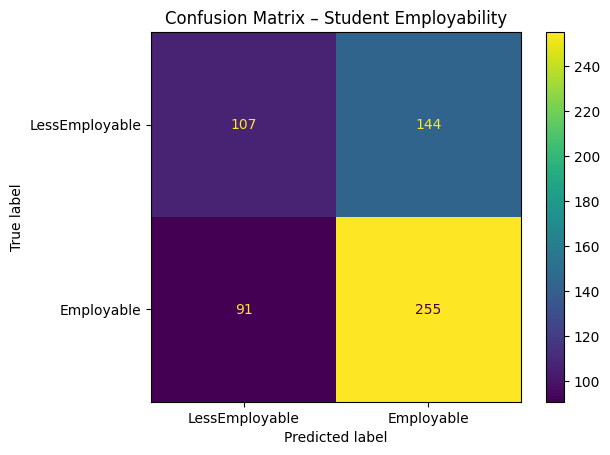

In [33]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "LessEmployable",
        "Employable"
    ]
)

disp.plot()
plt.title(
    "Confusion Matrix – Student Employability"
)
plt.show()


### Confusion Matrix Interpretation

For this model:

- **True Negative (TN):** A LessEmployable student correctly predicted as LessEmployable.
- **False Positive (FP):** A LessEmployable student incorrectly predicted as Employable.
- **False Negative (FN):** An Employable student incorrectly predicted as LessEmployable.
- **True Positive (TP):** An Employable student correctly predicted as Employable.

The confusion matrix shows not only how many predictions were correct, but also **which type of classification error occurred**.


## 14.2 Accuracy, Precision, Recall, and F1-Score

In [34]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

metrics_table = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

metrics_table


,Metric,Score
0,Accuracy,0.606
1,Precision,0.639
2,Recall,0.737
3,F1-score,0.685


### Metric Interpretation

With the fixed split used in this sample:

- **Accuracy** measures the percentage of all test students classified correctly.
- **Precision** measures how often an Employable prediction is actually Employable.
- **Recall** measures how many actual Employable students the model successfully identifies.
- **F1-score** balances precision and recall.

These metrics should be interpreted together rather than selecting a model based only on accuracy.


## 14.3 Classification Report

In [35]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "LessEmployable",
            "Employable"
        ]
    )
)


                precision    recall  f1-score   support

LessEmployable       0.54      0.43      0.48       251
    Employable       0.64      0.74      0.68       346

      accuracy                           0.61       597
     macro avg       0.59      0.58      0.58       597
  weighted avg       0.60      0.61      0.60       597



### Classification Report Interpretation

The baseline Logistic Regression model generally performs better at identifying the **Employable** class than the **LessEmployable** class.

This means that some students who are actually LessEmployable are predicted as Employable. The difference between class-specific recall values is important because overall accuracy alone does not reveal this imbalance in model performance.


# 15. Optional: Coefficients and Odds Ratios

Logistic Regression is useful because its coefficients can be interpreted.

Because predictors are standardized in the pipeline:

- a positive coefficient indicates higher predicted odds of being Employable as the rating increases;
- a negative coefficient indicates lower predicted odds;
- the odds ratio corresponds to approximately a **one-standard-deviation increase** in the predictor.

These values describe model associations and do not prove causation.


In [36]:
fitted_lr = model.named_steps[
    "classifier"
]

coefficients = fitted_lr.coef_[0]

coefficient_table = pd.DataFrame({
    "Feature": predictor_columns,
    "Coefficient": coefficients,
    "Odds_Ratio": np.exp(coefficients)
}).sort_values(
    "Odds_Ratio",
    ascending=False
)

coefficient_table


,Feature,Coefficient,Odds_Ratio
3,MENTAL ALERTNESS,0.395,1.484
1,MANNER OF SPEAKING,0.352,1.421
2,PHYSICAL CONDITION,0.055,1.056
0,GENERAL APPEARANCE,0.037,1.038
7,Student Performance Rating,0.004,1.004
4,SELF-CONFIDENCE,-0.018,0.982
6,COMMUNICATION SKILLS,-0.021,0.980
5,ABILITY TO PRESENT IDEAS,-0.300,0.740


### Coefficient Interpretation

The largest positive coefficients identify predictors most strongly associated with higher predicted employability after accounting for the other included ratings.

Because several interview skills are correlated with each other, individual coefficients should be interpreted cautiously. The model identifies conditional associations, not evidence that changing a single score will directly cause employability status to change.


# 16. Overall Interpretation

### 1. What was the final accuracy?

Using the fixed `random_state=42` split, the model achieves an accuracy of approximately **61%**.

### 2. Which class is predicted better?

The **Employable** class is predicted better, particularly in terms of recall.

### 3. Which class is more difficult to predict?

The **LessEmployable** class is more difficult for this baseline Logistic Regression model.

### 4. What does a false positive mean?

A student is actually LessEmployable according to the dataset but is predicted by the model as Employable.

### 5. What does a false negative mean?

A student is actually Employable but is predicted as LessEmployable.

### 6. Which error is more serious?

The answer depends on how the model is used. If the model were used to identify students who need additional employability training, a false positive could be important because a student needing support might incorrectly be treated as already employable. A false negative could also cause an employable student to be unnecessarily flagged for intervention.

### 7. Which evaluation metric is most important?

If the goal is balanced performance across the two classifications, **F1-score together with class-specific precision and recall** is more informative than accuracy alone.

### 8. Is accuracy alone sufficient?

No. The model performs differently across the two classes. A single accuracy value does not show that the LessEmployable class has weaker recall.

### 9. Which predictors show important patterns?

EDA indicates that **Mental Alertness** and **Manner of Speaking** have among the strongest simple positive associations with employability in this dataset. Other skills also contribute when modeled together.

### 10. Is Logistic Regression useful?

Logistic Regression provides an interpretable baseline, but the approximately 61% test accuracy indicates substantial room for improvement. The model should not be treated as a definitive employability assessment.


# 17. Conclusion

This laboratory activity used Logistic Regression to predict student employability classification from eight mock job-interview ratings. The dataset contained 2,982 student records, no missing values, and a binary target consisting of Employable and LessEmployable classifications. The student-name field was correctly excluded because it is an identifier rather than a meaningful predictor.

EDA showed moderate relationships among several interview skills and indicated that Mental Alertness and Manner of Speaking have some of the strongest simple associations with employability. Multicollinearity diagnostics did not indicate severe redundancy among the eight predictors. Because the predictors use short ordinal rating scales, the linear-log-odds assumption can only be assessed approximately, and this limitation should be recognized.

The Logistic Regression model achieved moderate predictive performance rather than near-perfect classification. With the fixed train-test split used in this notebook, overall accuracy is approximately 61%, and the model performs better at identifying Employable students than LessEmployable students. This demonstrates why the confusion matrix, precision, recall, and F1-score must be examined together with accuracy.

Overall, Logistic Regression is useful as a transparent baseline model for this dataset, but its performance suggests that employability classification cannot be explained perfectly by a simple linear combination of the eight ratings. Future work could compare alternative representations of the ordinal ratings, nonlinear classifiers, cross-validation, feature interactions, and other machine-learning algorithms.
